In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="vio3FVN5AAbW5HZUyqqY")
project = rf.workspace("college-k6ehm").project("trash-detection-hdig9")
version = project.version(2)
dataset = version.download("yolov11")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 12.9 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-genai 1.31.0 requires anyio<5.0.0,>=4.8.0, but you have anyio 3.7.1 which is incompatible.
tensorflow 2.17.1 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 6.32.0 which is incompatible.
wandb 0.19.1 requires protobuf!=4.21.0,!=5.28.0,<6,>=3.19.0; python_version > "3.9" and sys_platform == "linux", but


Extracting Dataset Version Zip to trash-detection-2 in yolov11:: 100%|██████████| 8984/8984 [00:01<00:00, 6265.42it/s]


In [ ]:
!pip install --upgrade ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 9.1 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")            # pick n/s/m/l/x depending on GPU size
results = model.train(
    data="/content/trash-detection-2/data.yaml",
    epochs=300,
    imgsz=640,
    batch=4,
    device=0,
    patience = 20,
    val=True,             # run validation each epoch
    lr0=0.001,            # initial learning rate
    optimizer="SGD",      # use SGD
    weight_decay=0.0001,  # L2 regularization
    momentum=0.9
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.193 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/trash-detection-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj

In [ ]:
metrics = model.val(data="/content/trash-detection-2/data.yaml")
print(metrics.box.map)  # mAP@0.5–0.95

Ultralytics 8.3.193 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 100 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1336.4±376.9 MB/s, size: 76.7 KB)
val: Scanning /content/trash-detection-2/valid/labels.cache... 902 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 902/902 1.1Mit/s 0.0s
val: /content/trash-detection-2/valid/images/img1644_jpg.rf.ef3527fe51f47e41903e8eb6e1e10324.jpg: 1 duplicate labels removed
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 675, len(boxes) = 2758. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 226/226 19.4it/s 11.6s
                   all        902       2758       0.69      0.542      0.585 


image 1/1 /content/trash-detection-2/train/images/img1534_jpg.rf.1755c20cd696f7c2db9faae7c6563e0d.jpg: 640x640 3 garbages, 15.2ms
Speed: 1.6ms preprocess, 15.2ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


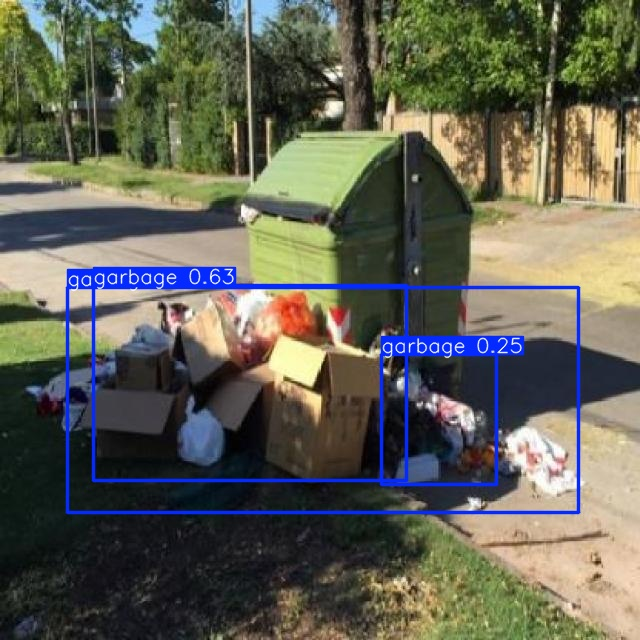

In [ ]:
from ultralytics import YOLO
from PIL import Image, ImageDraw

model = YOLO("runs/detect/train/weights/best.pt")

img = "/content/trash-detection-2/train/images/img1534_jpg.rf.1755c20cd696f7c2db9faae7c6563e0d.jpg"
pred = model(img)[0]
pred.save(filename="pred.jpg")   # draws boxes for a quick visual
Image.open("pred.jpg")